In [ ]:
# Numerical Libraries
import numpy as np
import pandas as pd

# Plotting Libraries
import matplotlib.pyplot as plt
import seaborn as sns

# Machine Learning Utilities
from sklearn.model_selection import train_test_split
from sklearn.preprocessing import StandardScaler

# Performance Metrics
from sklearn.metrics import (
    accuracy_score,
    precision_score,
    recall_score,
    f1_score,
    confusion_matrix,
    ConfusionMatrixDisplay
)

# Ignore warning messages
import warnings
warnings.filterwarnings("ignore")

plt.style.use("ggplot")

In [ ]:
feature_names = [
    "variance",
    "skewness",
    "curtosis",
    "entropy",
    "class"
]

data = pd.read_csv(
    "banknote_authentication.csv",
    header=None,
    names=feature_names
)

data.head()

,variance,skewness,curtosis,entropy,class
0,3.62160,8.6661,-2.8073,-0.44699,0
1,4.54590,8.1674,-2.4586,-1.46210,0
2,3.86600,-2.6383,1.9242,0.10645,0
3,3.45660,9.5228,-4.0112,-3.59440,0
4,0.32924,-4.4552,4.5718,-0.98880,0


In [ ]:
print("Dataset Shape :", data.shape)

print("\nInformation")
data.info()

print("\nMissing Values")
print(data.isna().sum())

print("\nStatistical Summary")
print(data.describe())

Dataset Shape : (1372, 5)

Information
<class 'pandas.core.frame.DataFrame'>
RangeIndex: 1372 entries, 0 to 1371
Data columns (total 5 columns):
 #   Column    Non-Null Count  Dtype  
---  ------    --------------  -----  
 0   variance  1372 non-null   float64
 1   skewness  1372 non-null   float64
 2   curtosis  1372 non-null   float64
 3   entropy   1372 non-null   float64
 4   class     1372 non-null   int64  
dtypes: float64(4), int64(1)
memory usage: 53.7 KB

Missing Values
variance    0
skewness    0
curtosis    0
entropy     0
class       0
dtype: int64

Statistical Summary
          variance     skewness     curtosis      entropy        class
count  1372.000000  1372.000000  1372.000000  1372.000000  1372.000000
mean      0.433735     1.922353     1.397627    -1.191657     0.444606
std       2.842763     5.869047     4.310030     2.101013     0.497103
min      -7.042100   -13.773100    -5.286100    -8.548200     0.000000
25%      -1.773000    -1.708200    -1.574975    -2.41345

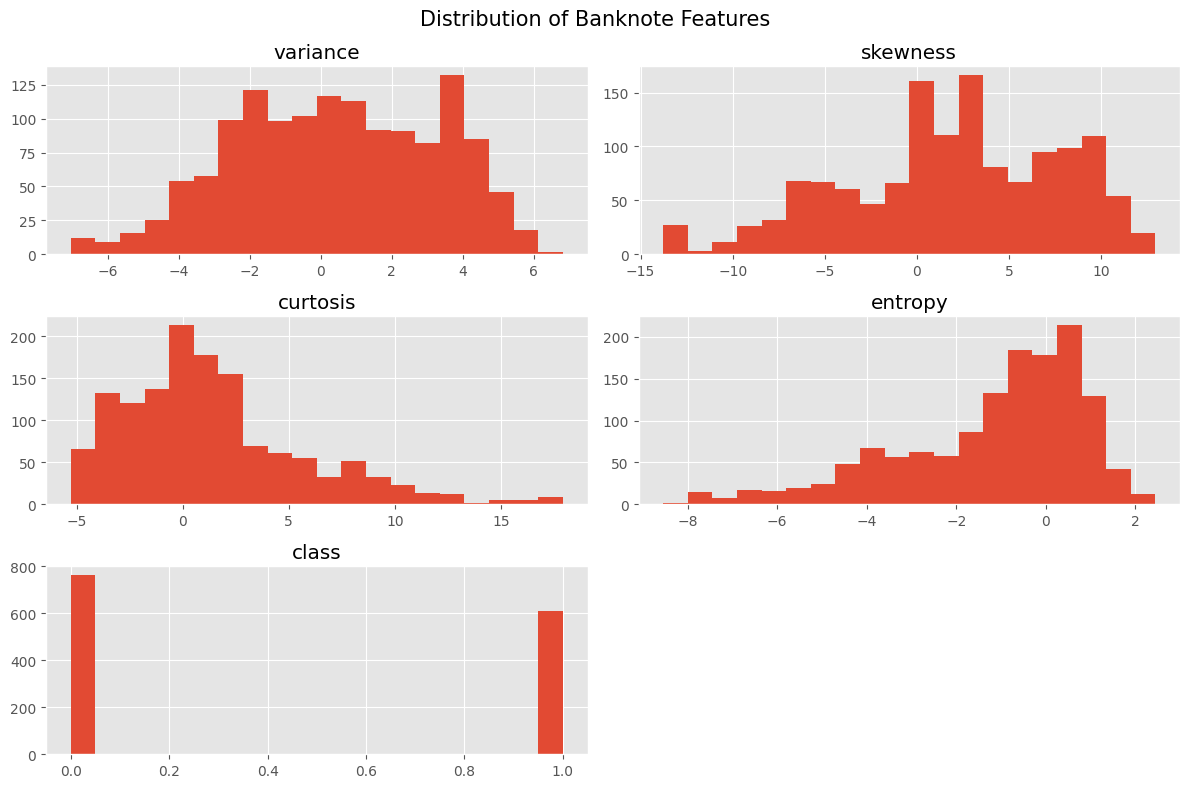

In [ ]:
data.hist(
    bins=20,
    figsize=(12,8)
)

plt.suptitle(
    "Distribution of Banknote Features",
    fontsize=15
)

plt.tight_layout()

plt.savefig(
    "histogram.eps",
    dpi=600,
    format="eps",
    bbox_inches="tight"
)

plt.show()

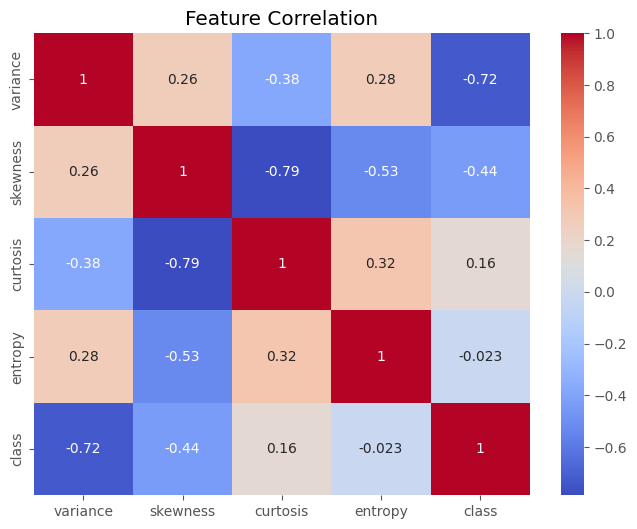

In [ ]:
plt.figure(figsize=(8,6))

correlation = data.corr()

sns.heatmap(
    correlation,
    annot=True,
    cmap="coolwarm"
)

plt.title("Feature Correlation")

plt.savefig(
    "heatmap.eps",
    dpi=600,
    format="eps",
    bbox_inches="tight"
)

plt.show()

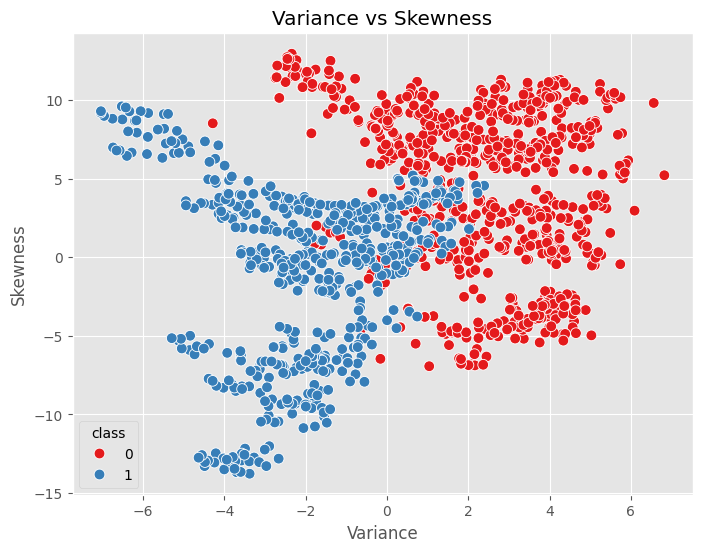

In [ ]:
plt.figure(figsize=(8,6))

sns.scatterplot(
    x="variance",
    y="skewness",
    hue="class",
    data=data,
    palette="Set1",
    s=60
)

plt.title("Variance vs Skewness")
plt.xlabel("Variance")
plt.ylabel("Skewness")

plt.savefig(
    "scatter.eps",
    dpi=600,
    format="eps",
    bbox_inches="tight"
)

plt.show()

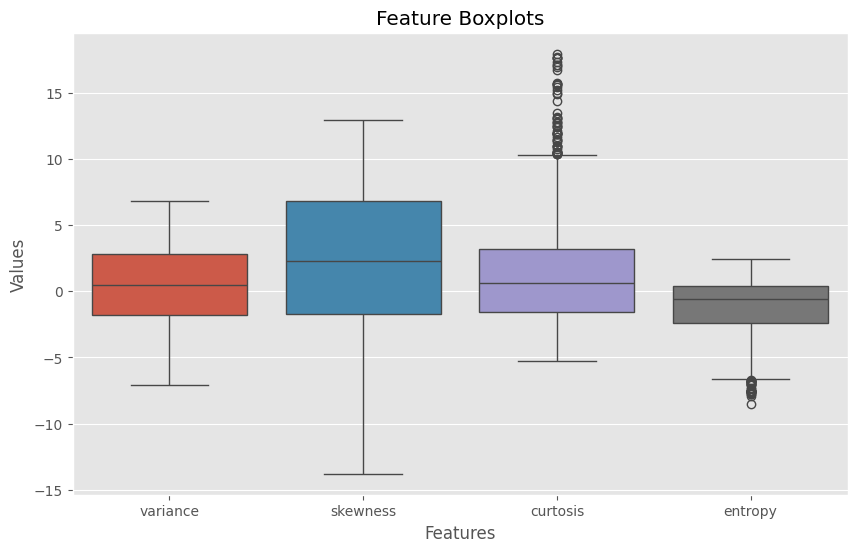

In [ ]:
plt.figure(figsize=(10,6))

sns.boxplot(
    data=data.iloc[:, :-1]
)

plt.title("Feature Boxplots")
plt.xlabel("Features")
plt.ylabel("Values")

plt.savefig(
    "boxplot.eps",
    dpi=600,
    format="eps",
    bbox_inches="tight"
)

plt.show()

In [ ]:
# Separate input and output

features = data.drop("class", axis=1)
target = data["class"]

# Split dataset

X_train, X_test, y_train, y_test = train_test_split(
    features,
    target,
    test_size=0.20,
    random_state=42,
    shuffle=True
)

In [ ]:
# Standardize the features

scale = StandardScaler()

X_train = scale.fit_transform(X_train)

X_test = scale.transform(X_test)

print("Training Data Shape :", X_train.shape)
print("Testing Data Shape  :", X_test.shape)

Training Data Shape : (1097, 4)
Testing Data Shape  : (275, 4)


In [ ]:
class PerceptronClassifier:

    def __init__(self, lr=0.01, epochs=50):

        self.lr = lr
        self.epochs = epochs

        self.weights = None
        self.bias = 0

        self.errors = []
        self.weight_history = []
        self.bias_history = []


    def activation(self, value):

        return 1 if value >= 0 else 0


    def initialize(self, n):

        self.weights = np.zeros(n)
        self.bias = 0


    def predict_single(self, sample):

        total = np.dot(sample, self.weights)

        total = total + self.bias

        return self.activation(total)


    def fit(self, X, y):

        self.initialize(X.shape[1])

        for epoch in range(self.epochs):

            mistake = 0

            for sample, actual in zip(X, y):

                predicted = self.predict_single(sample)

                difference = actual - predicted

                self.weights += self.lr * difference * sample

                self.bias += self.lr * difference

                if difference != 0:
                    mistake += 1

            self.errors.append(mistake)

            self.weight_history.append(
                self.weights.copy()
            )

            self.bias_history.append(
                self.bias
            )

            print(
                "Epoch",
                epoch + 1,
                "Errors =",
                mistake
            )

            print("Weights :", self.weights)

            print("Bias :", self.bias)

            print("-"*50)


    def predict(self, X):

        output = []

        for sample in X:

            result = self.predict_single(sample)

            output.append(result)

        return np.array(output)

In [ ]:
classifier = PerceptronClassifier()

print(classifier.activation(8))

print(classifier.activation(-6))

print(classifier.activation(0))

1
0
1


In [ ]:
classifier.initialize(4)

print("Initial Weights")

print(classifier.weights)

print("Initial Bias")

print(classifier.bias)

Initial Weights
[0. 0. 0. 0.]
Initial Bias
0


In [ ]:
classifier = PerceptronClassifier(
    lr=0.01,
    epochs=50
)

classifier.fit(
    X_train,
    y_train
)

predictions = classifier.predict(
    X_test
)

accuracy = accuracy_score(
    y_test,
    predictions
)

precision = precision_score(
    y_test,
    predictions
)

recall = recall_score(
    y_test,
    predictions
)

f1 = f1_score(
    y_test,
    predictions
)

print("Accuracy  :", accuracy)

print("Precision :", precision)

print("Recall    :", recall)

print("F1 Score  :", f1)

print()

matrix = confusion_matrix(
    y_test,
    predictions
)

print("Confusion Matrix")

print(matrix)

Epoch 1 Errors = 47
Weights : [-0.06920384 -0.06634441 -0.06529563 -0.00524322]
Bias : -0.03
--------------------------------------------------
Epoch 2 Errors = 22
Weights : [-0.07576842 -0.09439477 -0.05170347 -0.00312988]
Bias : -0.03
--------------------------------------------------
Epoch 3 Errors = 28
Weights : [-0.08628609 -0.10389484 -0.06133036 -0.00617938]
Bias : -0.03
--------------------------------------------------
Epoch 4 Errors = 24
Weights : [-0.09820347 -0.0939408  -0.08818487 -0.01037106]
Bias : -0.05
--------------------------------------------------
Epoch 5 Errors = 29
Weights : [-0.10984895 -0.12095156 -0.08618021  0.0003308 ]
Bias : -0.04
--------------------------------------------------
Epoch 6 Errors = 17
Weights : [-0.10385459 -0.13004831 -0.08702307  0.01372732]
Bias : -0.05
--------------------------------------------------
Epoch 7 Errors = 26
Weights : [-0.10982533 -0.11869946 -0.11825568 -0.01997855]
Bias : -0.05
-------------------------------------------

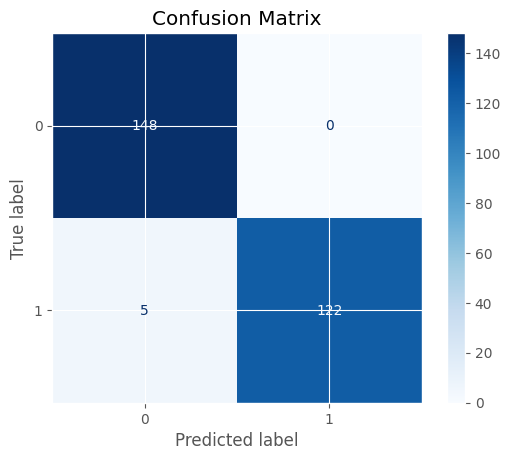

In [ ]:
display = ConfusionMatrixDisplay(
    confusion_matrix=matrix
)

display.plot(
    cmap="Blues"
)

plt.title("Confusion Matrix")

plt.savefig(
    "confusion_matrix.eps",
    dpi=600,
    format="eps",
    bbox_inches="tight"
)

plt.show()

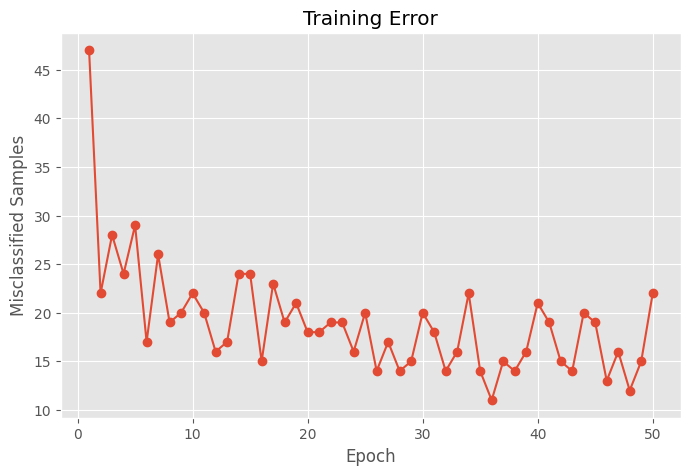

In [ ]:
plt.figure(figsize=(8,5))

plt.plot(
    range(1, len(classifier.errors)+1),
    classifier.errors,
    marker="o"
)

plt.title("Training Error")

plt.xlabel("Epoch")

plt.ylabel("Misclassified Samples")

plt.grid(True)

plt.savefig(
    "training_error.eps",
    dpi=600,
    format="eps",
    bbox_inches="tight"
)

plt.show()

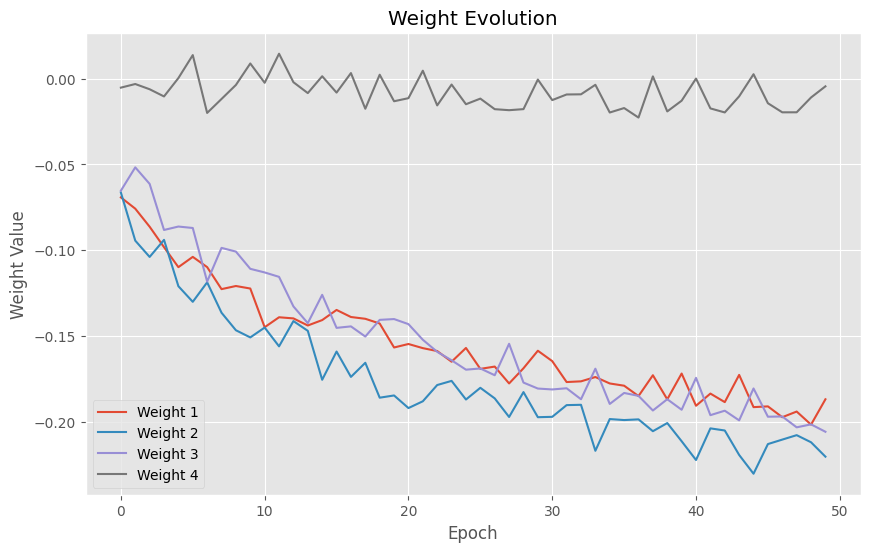

In [ ]:
weights = np.array(
    classifier.weight_history
)

plt.figure(figsize=(10,6))

for index in range(weights.shape[1]):

    plt.plot(
        weights[:, index],
        label=f"Weight {index+1}"
    )

plt.title("Weight Evolution")

plt.xlabel("Epoch")

plt.ylabel("Weight Value")

plt.legend()

plt.grid(True)

plt.savefig(
    "weight_evolution.eps",
    dpi=600,
    format="eps",
    bbox_inches="tight"
)

plt.show()

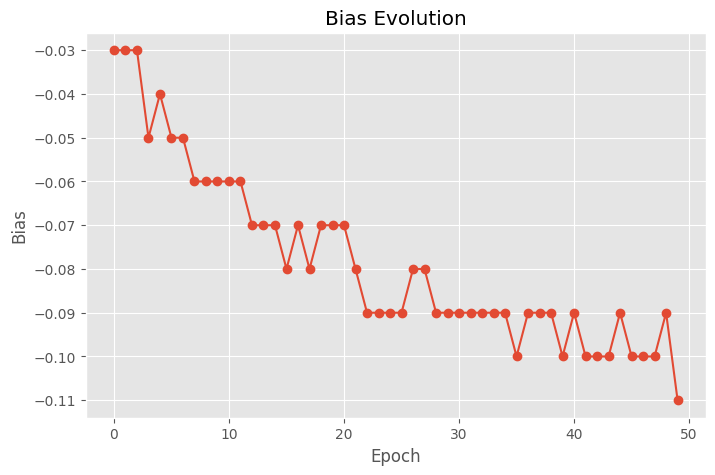

In [ ]:
plt.figure(figsize=(8,5))

plt.plot(
    classifier.bias_history,
    marker="o"
)

plt.title("Bias Evolution")

plt.xlabel("Epoch")

plt.ylabel("Bias")

plt.grid(True)

plt.savefig(
    "bias_evolution.eps",
    dpi=600,
    format="eps",
    bbox_inches="tight"
)

plt.show()

Epoch 1 Errors = 47
Weights : [-0.00692038 -0.00663444 -0.00652956 -0.00052432]
Bias : -0.003
--------------------------------------------------
Epoch 2 Errors = 22
Weights : [-0.00757684 -0.00943948 -0.00517035 -0.00031299]
Bias : -0.003
--------------------------------------------------
Epoch 3 Errors = 28
Weights : [-0.00862861 -0.01038948 -0.00613304 -0.00061794]
Bias : -0.003
--------------------------------------------------
Epoch 4 Errors = 24
Weights : [-0.00982035 -0.00939408 -0.00881849 -0.00103711]
Bias : -0.005
--------------------------------------------------
Epoch 5 Errors = 29
Weights : [-1.09848954e-02 -1.20951565e-02 -8.61802072e-03  3.30799957e-05]
Bias : -0.004
--------------------------------------------------
Epoch 6 Errors = 17
Weights : [-0.01038546 -0.01300483 -0.00870231  0.00137273]
Bias : -0.005
--------------------------------------------------
Epoch 7 Errors = 26
Weights : [-0.01098253 -0.01186995 -0.01182557 -0.00199786]
Bias : -0.005
--------------------

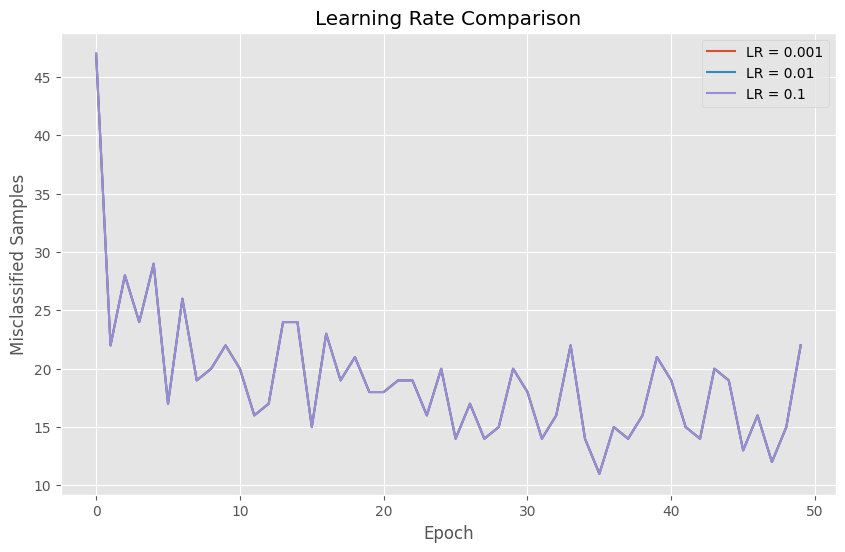

In [ ]:
rates = [
    0.001,
    0.01,
    0.1
]

plt.figure(figsize=(10,6))

for value in rates:

    temp = PerceptronClassifier(
        lr=value,
        epochs=50
    )

    temp.fit(
        X_train,
        y_train
    )

    plt.plot(
        temp.errors,
        label=f"LR = {value}"
    )

plt.title("Learning Rate Comparison")

plt.xlabel("Epoch")

plt.ylabel("Misclassified Samples")

plt.legend()

plt.grid(True)

plt.savefig(
    "learning_rate.eps",
    dpi=600,
    format="eps",
    bbox_inches="tight"
)

plt.show()